# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [42]:
cfg_file = '2026_02_09_smpd_v2.yml'
expt_path = r'C:\_Data\SMPD'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [43]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_02_14_18_07_1.0hrs', qubits=[1]


## Process data and add derived quantities

In [44]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

## Allan variance analysis

 C:\_Lib\python\slab_qick_calib\analysis\allan.py: 16RuntimeWarning: overflow encountered in exp
 C:\_Lib\python\slab_qick_calib\analysis\allan.py: 16

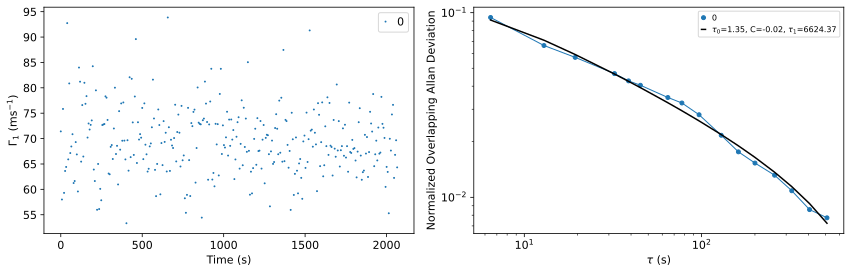

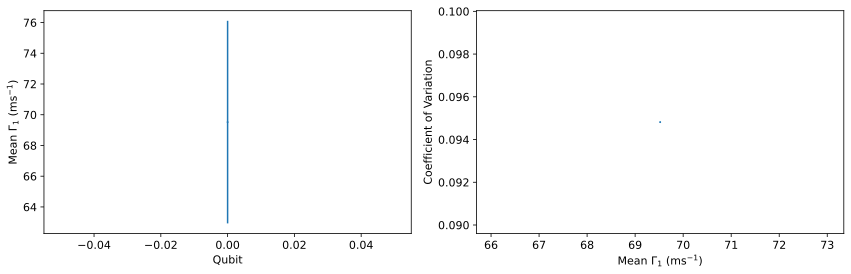

In [45]:
allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)

## Time series and histograms

Number of bad inds for t1 is 0
Number of bad inds for tphi is 39
Number of bad inds for f_ge is 14


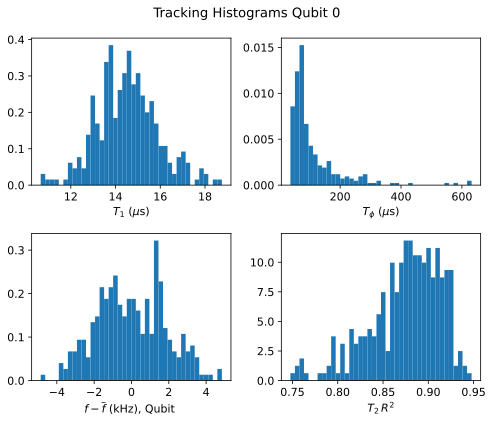

In [46]:
collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)

Number of bad inds for Gamma1 is 0
Number of bad inds for Gamma2 is 14
Number of bad inds for Gammaphi is 34


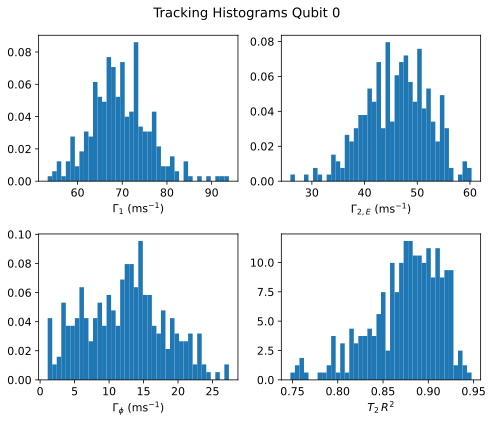

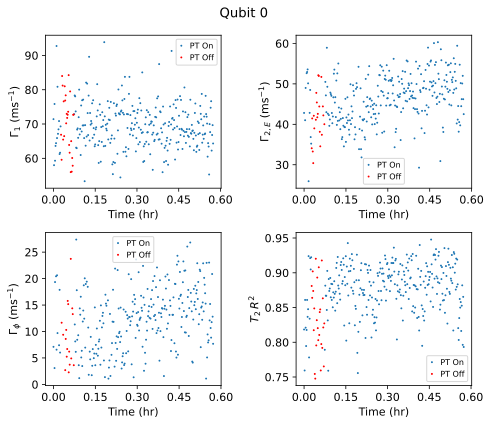

In [47]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 't2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)

## Violin plots

(<Figure size 700x600 with 4 Axes>,
 array([<AxesSubplot: xlabel='Qubit', ylabel='$\\Gamma_1$ (ms$^{-1}$)'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$\\Gamma_{\\phi}$ (ms$^{-1}$)'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$Q_1$'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$f-\\overline{f}$ (kHz), Qubit '>],
       dtype=object))

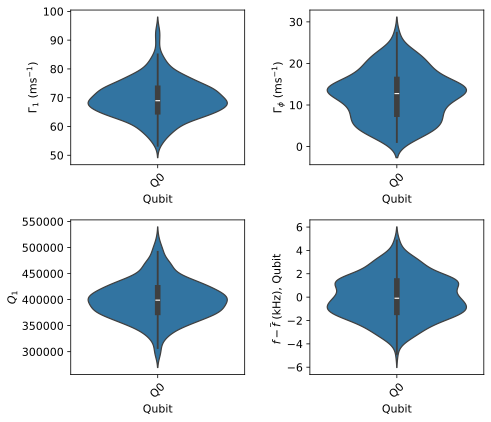

In [48]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)

## Power Spectral Density Analysis

Median time between measurements: 6.4 s
Sampling frequency: 0.1556 Hz

Analyzing Gamma1...


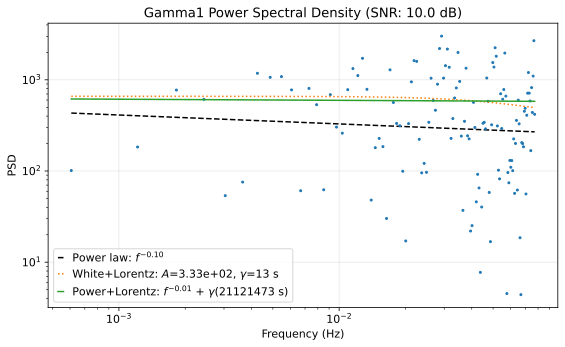

Peak frequency: 2.9178e-02 Hz (Period: 34.3 s)
Total power: 4.5504e+01
SNR: 10.0 dB

Analyzing Gammaphi...


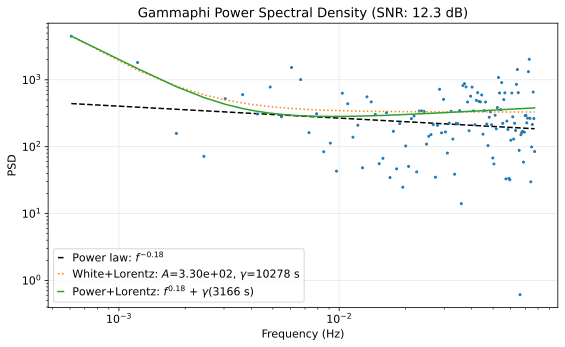

Peak frequency: 6.0787e-04 Hz (Period: 1645.1 s)
Total power: 2.9825e+01
SNR: 12.3 dB

Analyzing f_ge...


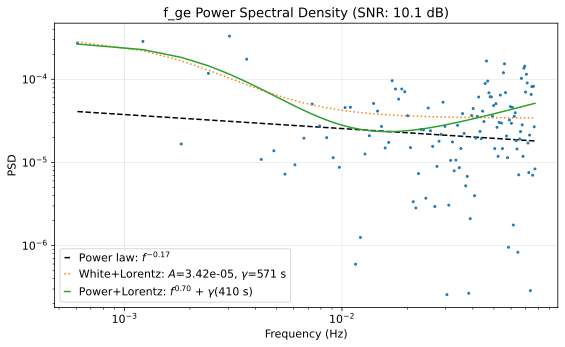

Peak frequency: 3.0394e-03 Hz (Period: 329.0 s)
Total power: 3.3278e-06
SNR: 10.1 dB

Analyzing t1...


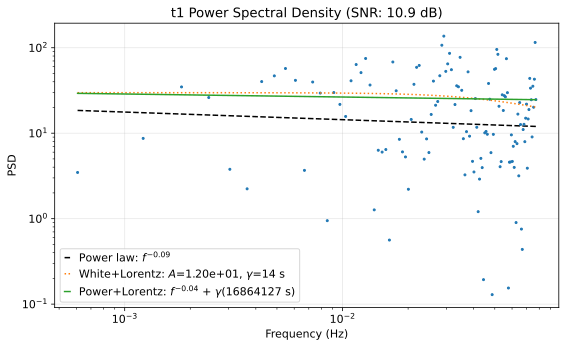

Peak frequency: 2.9178e-02 Hz (Period: 34.3 s)
Total power: 1.9734e+00
SNR: 10.9 dB


In [49]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

[(<Figure size 700x600 with 4 Axes>,
  array([<AxesSubplot: xlabel='MXC Temp (mK)', ylabel='$T_1$ ($\\mu$s)'>,
         <AxesSubplot: xlabel='MXC Temp (mK)', ylabel='$T_{\\phi}$ ($\\mu$s)'>,
         <AxesSubplot: xlabel='MXC Temp (mK)', ylabel='$f-\\overline{f}$ (kHz), Qubit '>,
         <AxesSubplot: xlabel='MXC Temp (mK)', ylabel='$\\Gamma_1$ (ms$^{-1}$)'>],
        dtype=object))]

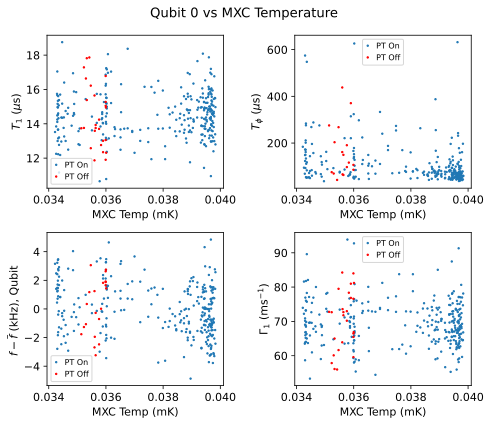

In [50]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

## Save stats to model config

In [51]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)